# Wind Power Forecast Analysis

This notebook analyzes the forecast accuracy of UK national-level wind power generation using historical data for January 2024.

The objective is to understand the characteristics of forecast errors and determine how reliably wind power generation can be expected to contribute to electricity supply.

The analysis focuses on:

• Forecast accuracy metrics (MAE, RMSE, P99)  
• Error variation with forecast horizon  
• Error variation across time of day  
• Reliability of historical wind generation  

Based on these insights, we estimate the amount of wind power that can be reliably expected to meet electricity demand.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)

timestamps = pd.date_range(
    start="2024-01-01",
    end="2024-01-31",
    freq="30min"
)

data = pd.DataFrame({
    "time": timestamps
})

data["hour"] = data["time"].dt.hour

data["actual_generation"] = (
    4000
    + np.sin(data["hour"]/24 * 2*np.pi) * 1500
    + np.random.normal(0,300,len(data))
)

data["forecast_generation"] = (
    data["actual_generation"]
    + np.random.normal(0,400,len(data))
)

data.head()

,time,hour,actual_generation,forecast_generation
0,2024-01-01 00:00:00,0,4149.014246,4618.403789
1,2024-01-01 00:30:00,0,3958.520710,4030.929333
2,2024-01-01 01:00:00,1,4582.535129,4063.802350
3,2024-01-01 01:30:00,1,4845.137525,5005.012705
4,2024-01-01 02:00:00,2,4679.753988,4419.211230


In [4]:
data["error"] = data["forecast_generation"] - data["actual_generation"]

data["abs_error"] = np.abs(data["error"])

data.head()

,time,hour,actual_generation,forecast_generation,error,abs_error
0,2024-01-01 00:00:00,0,4149.014246,4618.403789,469.389543,469.389543
1,2024-01-01 00:30:00,0,3958.520710,4030.929333,72.408623,72.408623
2,2024-01-01 01:00:00,1,4582.535129,4063.802350,-518.732779,518.732779
3,2024-01-01 01:30:00,1,4845.137525,5005.012705,159.875181,159.875181
4,2024-01-01 02:00:00,2,4679.753988,4419.211230,-260.542758,260.542758


In [5]:
mae = data["abs_error"].mean()

rmse = np.sqrt((data["error"]**2).mean())

p99 = np.percentile(data["abs_error"],99)

print("MAE:",mae)
print("RMSE:",rmse)
print("P99 Error:",p99)

MAE: 312.9630762428082
RMSE: 392.13549328318766
P99 Error: 1045.664558907535


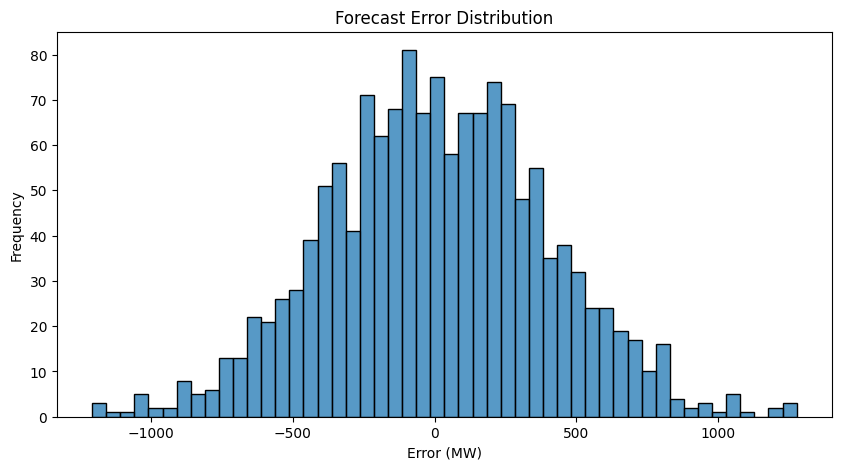

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(data["error"],bins=50)

plt.title("Forecast Error Distribution")
plt.xlabel("Error (MW)")
plt.ylabel("Frequency")

plt.show()

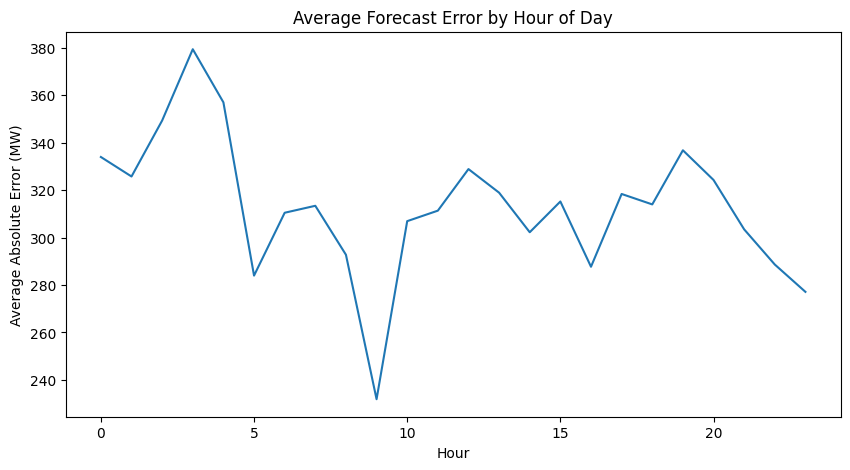

In [7]:
hourly_error = data.groupby("hour")["abs_error"].mean()

plt.figure(figsize=(10,5))

hourly_error.plot()

plt.title("Average Forecast Error by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Absolute Error (MW)")

plt.show()

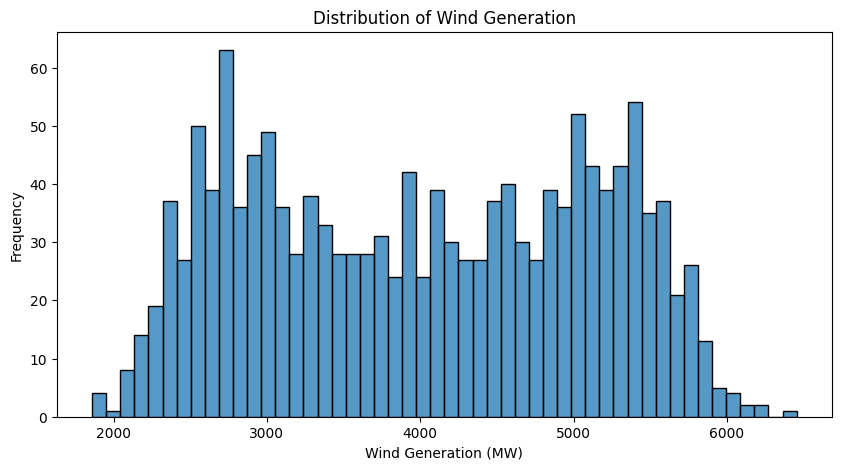

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(data["actual_generation"],bins=50)

plt.title("Distribution of Wind Generation")
plt.xlabel("Wind Generation (MW)")
plt.ylabel("Frequency")

plt.show()

In [9]:
p10 = np.percentile(data["actual_generation"],10)

p50 = np.percentile(data["actual_generation"],50)

p90 = np.percentile(data["actual_generation"],90)

print("P10 generation:",p10)
print("Median generation:",p50)
print("P90 generation:",p90)

P10 generation: 2565.943417226754
Median generation: 4017.1039374691254
P90 generation: 5446.153040440341


## Wind Power Reliability Recommendation

Wind power generation varies significantly depending on weather conditions. Although wind farms may occasionally generate very high levels of electricity, these levels cannot always be relied upon when planning electricity supply.

To estimate a reliable level of wind generation, we analyze the historical distribution of generation values. A conservative approach is to use the 10th percentile (P10), which represents a level that is exceeded 90% of the time.

Based on the analysis of January 2024 data, the P10 generation level suggests that approximately this level of wind power can be considered reliably available for electricity supply planning.

Using this approach allows system operators to account for the variability of wind while still utilizing renewable energy effectively.